## 汎用関数

### データをロード

In [8]:
import torch
import os
import sys
import torch.nn as nn
import numpy as np
import json

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from models import model_dict
from cka.LinearCKA import linear_CKA
from helper.util import safe_flatten_and_mean

from dataset.cifar10 import get_cifar10_dataloaders
from dataset.cifar100 import get_cifar100_dataloaders
from dataset.cinic10 import get_cinic10_dataloaders    

from helper.hooks import register_hooks

def load_model(model_name, n_cls, gpu=None, teacher=True):
    """Load teacher model using model directory"""
    if teacher:
        model_dir = os.path.join("..", "save", "teachers", "models", model_name)
    else:
        model_dir = os.path.join("..", "save", "students", "models", model_name)

    # --- parameters.json を読み込み ---
    param_path = os.path.join(model_dir, "parameters.json")
    if not os.path.exists(param_path):
        raise FileNotFoundError(f"parameters.json not found in {model_name}")

    with open(param_path, "r") as f:
        params = json.load(f)

    model_name = params["model"]

    # --- モデル構築 ---
    model = model_dict[model_name](num_classes=n_cls)

    # --- .pth ファイルを自動検出 ---
    pth_files = [f for f in os.listdir(model_dir) if f.endswith(".pth")]
    if not pth_files:
        raise FileNotFoundError(f"No .pth file found in {model_dir}")
    model_path = os.path.join(model_dir, pth_files[0])
    print(f"Loading weights: {pth_files[0]}")

    # --- CPU/GPU 両対応の map_location ---
    if torch.cuda.is_available() and gpu is not None:
        map_location = torch.device(f'cuda:{gpu}')
    else:
        map_location = torch.device('cpu')

    # --- 重み読み込み ---
    state_dict = torch.load(model_path, map_location=map_location)

    if "model" in state_dict:
        state_dict = state_dict["model"]

    model.load_state_dict(state_dict)

    return model, model_name



## 利用可能なモデルの一覧表示と取得

In [1]:
# List available models
import torchvision

all_models = torchvision.models.list_models()
classification_models = torchvision.models.list_models(module=torchvision.models)

# # Initialize models
# m1 = get_model("mobilenet_v3_large", weights=None)
# m2 = get_model("quantized_mobilenet_v3_large", weights="DEFAULT")

# # Fetch weights
# weights = get_weight("MobileNet_V3_Large_QuantizedWeights.DEFAULT")
# assert weights == MobileNet_V3_Large_QuantizedWeights.DEFAULT

# weights_enum = get_model_weights("quantized_mobilenet_v3_large")
# assert weights_enum == MobileNet_V3_Large_QuantizedWeights

# weights_enum2 = get_model_weights(torchvision.models.quantization.mobilenet_v3_large)
# assert weights_enum == weights_enum2

In [ ]:
model = "vgg"
for i in all_models:
    if model in i:
        print(i)

model = "vgg"
for i in classification_models:
    if model in i:
        print(i)

### モデルの確認

In [ ]:
import torchvision.models as models

model = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1)
model_name = "vgg16_bn"
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [4]:
import torch
import os
torch.save(model.state_dict(), os.path.join("save", "download", model_name))

## モデル削除or移動

In [64]:
import os
import shutil

who = "students"  # "teachers" または "students"
model_dir = os.path.join("save", who, "models")
tb_dir = os.path.join("save", who, "tensorboard")
cka_dir = os.path.join("save", "cka_logs")

# ==== モデル名 ==== 
names = [
"S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525",
"S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_065429",
"S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_034735",
]

# ==== オプション設定 ====
mode = "move"   # "delete" または "move"
dest = os.path.join("bin", "archive", who)  # mode="move" のとき移動先を指定

if mode == "move":
    if not dest:
        raise ValueError("mode='move' のときは dest を指定してください")
    os.makedirs(dest, exist_ok=True)

def remove_or_move(path, action, dest=None, prefix=None):
    if not os.path.exists(path):
        print(f"Skip (not found): {path}")
        return

    if action == "delete":
        print(f"Deleting: {path}")
        if os.path.isdir(path):
            shutil.rmtree(path)
        else:
            os.remove(path)

    elif action == "move":
        dst = os.path.join(dest, f"{prefix}_{os.path.basename(path)}")
        print(f"Moving: {path} -> {dst}")
        shutil.move(path, dst)

for name in names:
    m_path = os.path.join(model_dir, name)
    t_path = os.path.join(tb_dir, name)
    cka_path = os.path.join(cka_dir, "cka_log" + name)

    print("Processing:", name)
    print(m_path)

    if mode == "delete":
        remove_or_move(m_path, "delete")
        remove_or_move(t_path, "delete")
        remove_or_move(cka_path, "delete")

    elif mode == "move":
        remove_or_move(m_path, "move", dest, "model")
        remove_or_move(t_path, "move", dest, "tensorboard")
        remove_or_move(cka_path, "move", dest, "cka_log")



Processing: S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525
save/students/models/S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525
Moving: save/students/models/S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525 -> bin/archive/students/model_S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525
Moving: save/students/tensorboard/S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525 -> bin/archive/students/tensorboard_S_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525
Skip (not found): save/cka_logs/cka_logS_vgg16_bn-T_vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_100.0-20251220_003525
Processing: S_vgg16_bn-T_vgg16_bn_ha

## .pthの中身を確認

In [11]:
import torch
import os

# 1つ目のファイル
file_path1 = r"..\ckad0818\save\teachers_VGG13\models\vgg13-vanilla-cifar10-trial_0-epochs_240-bs_64-20250903\vgg13_best.pth"
state1 = torch.load(file_path1, map_location="cpu")
print("Keys in first file:", state1.keys())
size1 = os.path.getsize(file_path1)
print("File size:", size1, "bytes")
# print("Keys in state_dict:")
# for k, v in state1['model'].items():
#     print(f"{k}: {tuple(v.shape) if hasattr(v, 'shape') else 'scalar'} - dtype: {v.dtype} - size: {v.numel()*v.element_size()/1024/1024:.2f} MB")


# 2つ目のファイル
file_path2 = r"save\teachers\models\vgg13_bn-cifar10-trial_0-epochs_1-bs_64-20251010_115552\vgg13_bn_best.pth"
state2 = torch.load(file_path2, map_location="cpu")
print("Keys in second file:", state2.keys())
size2 = os.path.getsize(file_path2)
print("File size:", size2, "bytes")
# print("Keys in state_dict:")
# for k, v in state2['model'].items():
#     print(f"{k}: {tuple(v.shape) if hasattr(v, 'shape') else 'scalar'} - dtype: {v.dtype} - size: {v.numel()*v.element_size()/1024/1024:.2f} MB")



Keys in first file: dict_keys(['epoch', 'best_acc', 'model'])
File size: 37711138 bytes
Keys in second file: dict_keys(['epoch', 'best_acc', 'model'])
File size: 37711366 bytes


## モデル図示・パラメータ数表示

In [1]:
import torch
import torch.nn as nn

def count_params(module):
    return sum(p.numel() for p in module.parameters())

def print_model_structure_with_params(model, show_module_names=True):
    print("=== Model Structure ===\n")

    total_params = 0
    layer_id = 0

    for name, module in model.named_children():

        # BasicBlock などのブロック
        if isinstance(module, nn.Sequential) or "layer" in name:
            if show_module_names: 
                print(f"{name}:")
            for block in module:
                layer_id += 1
                params = count_params(block)
                total_params += params
                if show_module_names:
                    print(f"  ├─ Block {layer_id} ({block.__class__.__name__})  | Params: {params:,}")
                    for subname, submodule in block.named_children():
                        sub_params = count_params(submodule)
                        print(f"      ├─ ({subname}) {submodule}  | Params: {sub_params:,}")
            print()

        # FC や Conv などの通常層
        else:
            params = count_params(module)
            total_params += params
            if show_module_names:
                print(f"(Layer) {name}: {module}  | Params: {params:,}")

    print("\n=== Total Parameters ===")
    print(f"Total: {total_params:,} parameters\n")


 
def print_model_structure_simple(model):
    # for name, m in model.named_modules():
    #     print(f"{name}: {m}")
    for idx, (name, module) in enumerate(model.named_modules()):
        print(f"Checking layer: {name}")  # デバッグ用出力
    total_params = sum(p.numel() for p in model.parameters())
    print("\n=== Total Parameters ===") 
    print(f"Total: {total_params:,} parameters\n")


In [2]:
from models import model_dict
n_cls = {
    'cifar10':10,
    'cifar100': 100,
    'imagenet': 1000,
    'cinic10': 10
}

models = [
    "resnet14",
    "vgg16_bn",
]

for model in models:
    print(f"{model} Model Structure:")
    net = model_dict[model](num_classes=n_cls['cifar100'])
    print_model_structure_with_params(net, show_module_names=True)
    print_model_structure_simple(net)





resnet14 Model Structure:
=== Model Structure ===

(Layer) conv1: Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)  | Params: 432
(Layer) bn1: BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)  | Params: 32
(Layer) relu: ReLU(inplace=True)  | Params: 0
layer1:
  ├─ Block 1 (BasicBlock)  | Params: 4,672
      ├─ (conv1) Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)  | Params: 2,304
      ├─ (bn1) BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)  | Params: 32
      ├─ (relu) ReLU(inplace=True)  | Params: 0
      ├─ (conv2) Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)  | Params: 2,304
      ├─ (bn2) BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)  | Params: 32
  ├─ Block 2 (BasicBlock)  | Params: 4,672
      ├─ (conv1) Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)  | Params:

### モデル描画

In [ ]:
from torchview import draw_graph

# 画像をNotebook上で直接表示
graph = draw_graph(
    model,
    input_size=(1, 3, 32, 32),  # 入力テンソルサイズ
    expand_nested=False,         # ネストされたSequentialなどを展開するか
    depth=3,                     # 表示する階層の深さを制限
    hide_inner_tensors=True,     # 中間テンソル（shape情報）を非表示
    save_graph=False,            # 自動保存をオフ（Jupyter向け）
    device="cpu",                # モデルを動かすデバイス
    graph_name="model_graph",    # 出力名
)
graph.visual_graph

# ファイルに保存
# graph.visual_graph.render("vgg_torchview", format="png")  # ファイル保存
# display(Image(filename="vgg_torchview.png"))  # Notebookに表示


## 特定の層を取得

In [11]:
import torch
import torch.nn as nn
# FeatureHook class（中間特徴記録）
class FeatureHook:
    def __init__(self):
        self.outputs = []

    def __call__(self, module, input, output):
        self.outputs.append(output)
        
def register_hooks(
    model_name,
    model,
    *,
    # bn_suffixes=None,        # 例: ["bn2"] / ["bn1","bn2"]
    # linear_names=None,       # 例: ["fc", "classifier.6"]
    spatial_avg=False
):
    # ===== モデル別設定 =====
    if "resnet" in model_name:
        bn_suffixes = ["bn2"]
        linear_names = ["fc"]

    elif "vgg" in model_name:
        bn_suffixes = [
            name for name, m in model.named_modules()
            if isinstance(m, nn.BatchNorm2d)
        ]
        linear_names = ["classifier"]

    else:
        bn_suffixes = []
        linear_names = []

    hooks = []
    feature_hook = FeatureHook()  # ← そのまま

    EXCLUDED_LAYERS = ['layer1.0.downsample.1']

    for idx, (name, module) in enumerate(model.named_modules()):
        print(f"Checking layer: {name}")

        if name in EXCLUDED_LAYERS:
            continue

        register = False

        if isinstance(module, nn.BatchNorm2d):
            if any(name.endswith(suf) for suf in bn_suffixes):
                print(f"[HOOK BN] {name}")
                register = True

        if isinstance(module, nn.Linear):
            if name in linear_names:
                print(f"[HOOK FC] {name}")
                register = True

        if register:
            handle = module.register_forward_hook(feature_hook)
            hooks.append((idx, name, handle))

    return hooks, feature_hook

def register_hooks_conv(
    model_name,
    model,
    *,
    spatial_avg=False,
):
    """
    Register forward hooks on Conv2d layers.

    Args:
        model_name (str): name of the model (for logging).
        model (nn.Module): target model.
        spatial_avg (bool): whether to apply spatial average later (handled in FeatureHook).

    Returns:
        hooks (list): list of (idx, layer_name, hook_handle)
        feature_hook (FeatureHook): hook object storing features
    """
    EXCLUDED_LAYERS = {"layer1.0.downsample.1"}
    feature_hook = FeatureHook()
    hooks = []

    # 候補層を選ぶ
    if "vgg" in model_name.lower():
        conv_layers = [(idx, name, module)
                       for idx, (name, module) in enumerate(model.named_modules())
                       if isinstance(module, nn.Conv2d)]
    elif "resnet" in model_name.lower():
        conv_layers = [(idx, name, module)
                       for idx, (name, module) in enumerate(model.named_modules())
                       if isinstance(module, nn.Conv2d) and "downsample" not in name and name not in EXCLUDED_LAYERS]
    else:
        conv_layers = [(idx, name, module)
                       for idx, (name, module) in enumerate(model.named_modules())
                       if isinstance(module, nn.Conv2d)]

    if len(conv_layers) == 0:
        raise RuntimeError("No Conv2d layers found.")

    # 中間層を選ぶ
    mid_idx = len(conv_layers) // 2
    idx, name, module = conv_layers[mid_idx]
    print(f"Hook target: {name} at index {idx}")

    # その層だけ hook
    handle = module.register_forward_hook(feature_hook)
    hooks.append((idx, name, handle))

    return hooks, feature_hook



In [15]:
import torch
import torch.nn as nn

model_name = "vgg16"

model = model_dict[model_name](num_classes=100)
model.eval()

hooks, feats = register_hooks_conv(
    model_name=model_name,
    model=model,
)


Final output channels before classifier: 512
Hook target: block2.6 at index 20


## モデル一覧

In [17]:
import os
import re

target = "students"

base_dir = os.path.join("save", target)
model_dir = os.path.join(base_dir, "models")
tb_dir = os.path.join(base_dir, "tensorboard")

# ==== 両方に存在する名前を取得（ファイルでもフォルダでもOK） ====
common_items = set(os.listdir(model_dir)) & set(os.listdir(tb_dir))

# ==== ファイル名末尾の日付時刻 YYYYMMDD_HHMMSS を取得する関数 ====
def extract_datetime(name):
    m = re.search(r"(\d{8}_\d{6})$", name)
    return m.group(1) if m else ""   # 見つからなければ空文字

# ==== 日付でソート ====
sorted_items = sorted(common_items, key=extract_datetime, reverse=True)

# ==== 出力 ====
for i in sorted_items:
    print(f"\"{i}\",")


"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_200.0-20251231_043534",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_200.0-20251231_035909",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_031934",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_024130",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_020210",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_10.0-20251231_012357",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_10.0-20251231_004604",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_10.0-20251231_000808",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251230_230301",

In [21]:
import os
import re

target = "teachers"

base_dir = os.path.join("save", target)
model_dir = os.path.join(base_dir, "models")
tb_dir = os.path.join(base_dir, "tensorboard")

# ==== 両方に存在する名前を取得（ファイルでもフォルダでもOK） ====
common_items = set(os.listdir(model_dir)) & set(os.listdir(tb_dir))

# ==== ファイル名末尾の日付時刻 YYYYMMDD_HHMMSS を取得する関数 ====
def extract_datetime(name):
    m = re.search(r"(\d{8}_\d{6})$", name)
    return m.group(1) if m else ""   # 見つからなければ空文字

# ==== 日付でソート ====
sorted_items = sorted(common_items, key=extract_datetime, reverse=True)

# ==== 出力 ====
for i in sorted_items:
    print(f"\"{i}\",")

"resnet38-cifar100-trial_0-epochs_240-bs_64-20251230_140325",
"resnet38-cifar100-trial_0-epochs_240-bs_64-20251230_134702",
"resnet38-cifar100-trial_0-epochs_240-bs_64-20251230_133042",
"resnet38-cifar100-trial_0-epochs_240-bs_64-20251230_131420",
"resnet38x2-cifar100-trial_0-epochs_1-bs_64-20251227_164407",
"resnet38-cifar100-trial_0-epochs_240-bs_64-20251226_205340",
"resnet38x2-cifar100-trial_0-epochs_240-bs_64-20251226_175731",
"resnet38x2-cifar100-trial_0-epochs_240-bs_64-20251226_140410",
"resnet8x2-cifar100-trial_0-epochs_240-bs_64-20251223_194435",
"resnet8x2-cifar100-trial_0-epochs_240-bs_64-20251223_192054",
"resnet8x2-cifar100-trial_0-epochs_240-bs_64-20251223_185535",
"resnet8x2-cifar100-trial_0-epochs_240-bs_64-20251223_183003",
"resnet8x2-cifar100-trial_0-epochs_240-bs_64-20251223_180541",
"resnet8x2-cifar100-trial_0-epochs_240-bs_64-20251223_180508",
"resnet14x2-cifar100-trial_0-epochs_240-bs_64-20251223_134842",
"resnet14x2-cifar100-trial_0-epochs_240-bs_64-20251223_124

## 特定のパラメータをもつモデルの一覧

In [14]:
import json
import os
def match_params(params, conditions):
    for k, v in conditions.items():
        if k not in params or params[k] != v:
            return False
    return True

def find_models_multi(base_dir, conditions):
    matched_models = []
    for root, dirs, files in os.walk(base_dir):
        if "parameters.json" in files:
            with open(os.path.join(root, "parameters.json")) as f:
                params = json.load(f)
            if match_params(params, conditions):
                # 一番下のフォルダ名だけを取得
                model_name = os.path.basename(root)
                matched_models.append(model_name)
    return matched_models




In [15]:
# 使用例

conditions = {"batch_size": 64, "epochs": 240, "dataset": "cifar100", 
              "model": "vgg16_bn_half", "model_t": "vgg16_bn",
              "distill":"kd"}
              # "beta":1.0}
            #   "layer_usage":"key", "group_num": 6}
# conditions = {"batch_size": 64, "epochs": 240, "dataset": "cifar100", 
#               "model": "resnet8x2", "model_t": "resnet14x2",
#               "distill":"hint"}
              # "layer_usage":"all", "group_num": 4}


models = find_models_multi("save/students/models", conditions)
for m in models:
    print("\"", m, "\"", ",", sep="")

"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_1.0-20251229_184716",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_10.0-20251030_150951",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_10.0-20251030_154459",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_100.0-20251030_221622",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_100.0-20251030_224208",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_100.0-20251031_140555",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_100.0-20251031_194052",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_100.0-20251104_143420",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-kd-cls_1.0-div_1.0-beta_100.0-20251127_090028",
"S_vgg16_bn_ha

# モデルの詳細表示

In [2]:
import json
import os
def show_json_info(json_path, keys=None):
    """
    JSONファイルの内容を表示する関数。
    keys を None にすると全項目を表示。
    keys にリストを渡すと、その項目だけ表示。
    """
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"[Error] File not found: {json_path}")
        return
    except json.JSONDecodeError:
        print(f"[Error] Invalid JSON format: {json_path}")
        return

    # print(f"=== {json_path} ===")

    # keysが指定されていない場合 → 全項目出力
    if keys is None:
        for key, value in data.items():
            print(f"{key}: {value}")
    else:
        # 指定されたキーのみ出力
        for key in keys:
            if key in data:
                print(f"{key}: {data[key]}")
            else:
                print(f"{key}: [キーが存在しません]")
import json

def load_json(json_path):
    with open(json_path, "r", encoding="utf-8") as f:
        return json.load(f)


def compare_jsons(json_paths, keys=None):
    """
    複数JSONの中身を比較する
    keys=None -> 全キー比較
    keys=[...] -> 指定キーのみ比較
    """
    base_path = json_paths[0]
    base = load_json(base_path)

    # 比較対象キーを決定
    if keys is None:
        compare_keys = set(base.keys())
    else:
        compare_keys = set(keys)

    print(f"[BASE] {base_path}")
    print(f"Compare keys: {sorted(compare_keys)}")

    for path in json_paths[1:]:
        data = load_json(path)
        diff = {}

        for k in compare_keys:
            if base.get(k) != data.get(k):
                diff[k] = (base.get(k), data.get(k))

        if diff:
            print(f"\n❌ Difference found: {path}")
            for k, (v0, v1) in diff.items():
                print(f"  {k}: base={v0}, current={v1}")
        else:
            print(f"\n✅ Same config: {path}")


In [3]:
files = [
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251230_230301",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251230_222607",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_031934",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_024130",
"S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_020210",

 ]

keys = ["batch_size", 
        "model", "model_name_t", "model_t",
        "distill", "beta", "layer_usage", "group_num"]
key_show = keys + ["log_cka"]
json_paths = []
for path in files:
    # print("\n=== ", path, " ===", sep="")
    json_path = os.path.join("save", "students", "models", path, "parameters.json")
    json_paths.append(json_path)
compare_jsons(json_paths, keys)
for path in files:
    print("\n=== ", path, " ===", sep="")
    json_path = os.path.join("save", "students", "models", path, "parameters.json")
    show_json_info(json_path, key_show)


[BASE] save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251230_230301\parameters.json
Compare keys: ['batch_size', 'beta', 'distill', 'group_num', 'layer_usage', 'model', 'model_name_t', 'model_t']

✅ Same config: save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251230_222607\parameters.json

✅ Same config: save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_031934\parameters.json

✅ Same config: save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_024130\parameters.json

✅ Same config: save\students\models\S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_50.0-20251231_020210\parameters.json

=== S_vgg16_bn_half-T_vgg16_bn-cifar100-trial_0-epochs_240-bs_64-ckad-cls_1.0-div_1.0-beta_

In [28]:
files = [
"vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_090714",
"vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_093846",
"vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_101017",
"vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_104150",
"vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_111323",
]

keys = ["batch_size", 
        "model", "model_name", "model_t",
        "distill", "beta", "layer_usage", "group_num"]
json_paths = []
for path in files:
    # print("\n=== ", path, " ===", sep="")
    json_path = os.path.join("save", "teachers", "models", path, "parameters.json")
    json_paths.append(json_path)
compare_jsons(json_paths, keys)
for path in files:
    print("\n=== ", path, " ===", sep="")
    json_path = os.path.join("save", "teachers", "models", path, "parameters.json")
    show_json_info(json_path, keys)


[BASE] save\teachers\models\vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_090714\parameters.json
Compare keys: ['batch_size', 'beta', 'distill', 'group_num', 'layer_usage', 'model', 'model_name', 'model_t']

✅ Same config: save\teachers\models\vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_093846\parameters.json

✅ Same config: save\teachers\models\vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_101017\parameters.json

✅ Same config: save\teachers\models\vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_104150\parameters.json

✅ Same config: save\teachers\models\vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_111323\parameters.json

=== vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114_090714 ===
batch_size: 64
model: vgg16_bn_half
model_name: vgg16_bn_half-cifar100-trial_0-epochs_240-bs_64-20251114
model_t: [キーが存在しません]
distill: [キーが存在しません]
beta: [キーが存在しません]
layer_usage: [キーが存在しません]
group_num: [キーが存在しません]

=== vgg16_bn_half-cifar100-

# 画像データの確認

Class 0: apple
Class 1: aquarium_fish
Class 2: baby
Class 4: beaver
Class 13: bus


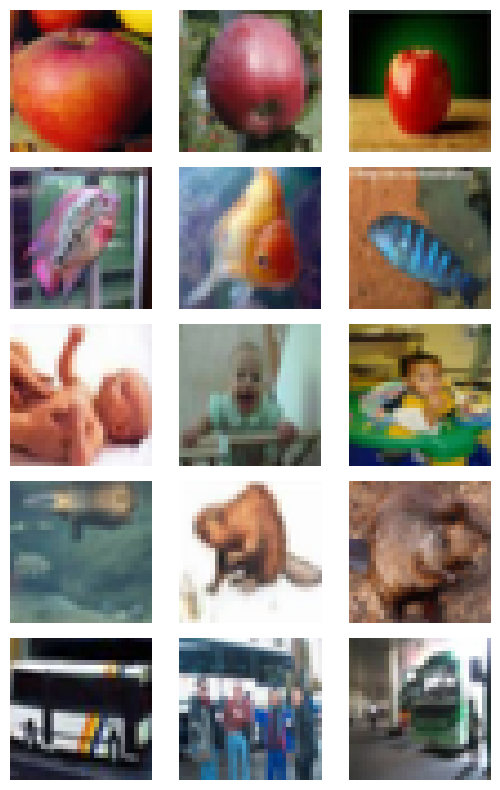

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ----------------------------
# 設定
# ----------------------------
NUM_CLASSES = 5
IMAGES_PER_CLASS = 3
SAVE_PATH = "cifar100_vertical_grid_named.png"
DATA_ROOT = "../data"   # CIFAR100保存先

# CIFAR-100 正規化パラメータ
CIFAR100_MEAN = np.array([0.5071, 0.4867, 0.4408])
CIFAR100_STD  = np.array([0.2675, 0.2565, 0.2761])

def denormalize(img):
    """
    img: Tensor (C,H,W) normalized
    return: numpy (H,W,C) in [0,1]
    """
    img = img.permute(1, 2, 0).cpu().numpy()
    img = img * CIFAR100_STD + CIFAR100_MEAN
    img = np.clip(img, 0, 1)
    return img

# ----------------------------
# 可視化用 transform（拡張なし）
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# ----------------------------
# dataset / dataloader
# ----------------------------
dataset = datasets.CIFAR100(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset, batch_size=256, shuffle=True)

class_names = dataset.classes  # クラス名取得

# ----------------------------
# クラスごとに画像収集
# ----------------------------
class_images = {i: [] for i in range(100)}

for images, labels in loader:
    for img, label in zip(images, labels):
        label = int(label.item())
        if len(class_images[label]) < IMAGES_PER_CLASS:
            class_images[label].append(img)

    collected = [k for k,v in class_images.items() if len(v) >= IMAGES_PER_CLASS]
    if len(collected) >= NUM_CLASSES:
        break

selected_classes = list(collected)[:NUM_CLASSES]

# ----------------------------
# グリッド描画（縦＝クラス、横＝画像）
# ----------------------------
fig, axes = plt.subplots(
    NUM_CLASSES, IMAGES_PER_CLASS,
    figsize=(IMAGES_PER_CLASS*1.8, NUM_CLASSES*1.6)
)

if NUM_CLASSES == 1:
    axes = np.expand_dims(axes, 0)
if IMAGES_PER_CLASS == 1:
    axes = np.expand_dims(axes, 1)

for row, cls in enumerate(selected_classes):
    class_name = class_names[cls]
    print(f"Class {cls}: {class_name}")

    for col in range(IMAGES_PER_CLASS):
        img = class_images[cls][col]
        img = denormalize(img)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                f"{class_name}\n(class {cls})",
                fontsize=9,
                rotation=0,
                labelpad=45,
                va='center'
            )

plt.tight_layout()
plt.show()
# plt.savefig(SAVE_PATH, dpi=300)
plt.close()


In [7]:
class_names

['apple',
 'aquarium_fish',
 'baby',
 'bear',
 'beaver',
 'bed',
 'bee',
 'beetle',
 'bicycle',
 'bottle',
 'bowl',
 'boy',
 'bridge',
 'bus',
 'butterfly',
 'camel',
 'can',
 'castle',
 'caterpillar',
 'cattle',
 'chair',
 'chimpanzee',
 'clock',
 'cloud',
 'cockroach',
 'couch',
 'crab',
 'crocodile',
 'cup',
 'dinosaur',
 'dolphin',
 'elephant',
 'flatfish',
 'forest',
 'fox',
 'girl',
 'hamster',
 'house',
 'kangaroo',
 'keyboard',
 'lamp',
 'lawn_mower',
 'leopard',
 'lion',
 'lizard',
 'lobster',
 'man',
 'maple_tree',
 'motorcycle',
 'mountain',
 'mouse',
 'mushroom',
 'oak_tree',
 'orange',
 'orchid',
 'otter',
 'palm_tree',
 'pear',
 'pickup_truck',
 'pine_tree',
 'plain',
 'plate',
 'poppy',
 'porcupine',
 'possum',
 'rabbit',
 'raccoon',
 'ray',
 'road',
 'rocket',
 'rose',
 'sea',
 'seal',
 'shark',
 'shrew',
 'skunk',
 'skyscraper',
 'snail',
 'snake',
 'spider',
 'squirrel',
 'streetcar',
 'sunflower',
 'sweet_pepper',
 'table',
 'tank',
 'telephone',
 'television',
 'tig

In [14]:
a = [
    # intro
    20,15,30,30,45,
    # related work
    50,40,45,80,30,30,
    # method
    40,70,30,
    # exp
    60, 60, # setup
    20, # acc
    70, # acc epoch
    60, # cka
    50, # weight ablation
    # last
    70,50,60
    ]

total = 0
for i in a:
    total = total + i
print(total, "/", 60*20)

1055 / 1200
